In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data_source/breast_cancer_dataset.csv')

## Checking the dataset for cleaning

In [3]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
df.shape          # should be (569, 31)


(569, 33)

In [7]:
df.drop(['Unnamed: 32','id'], axis=1, inplace=True)

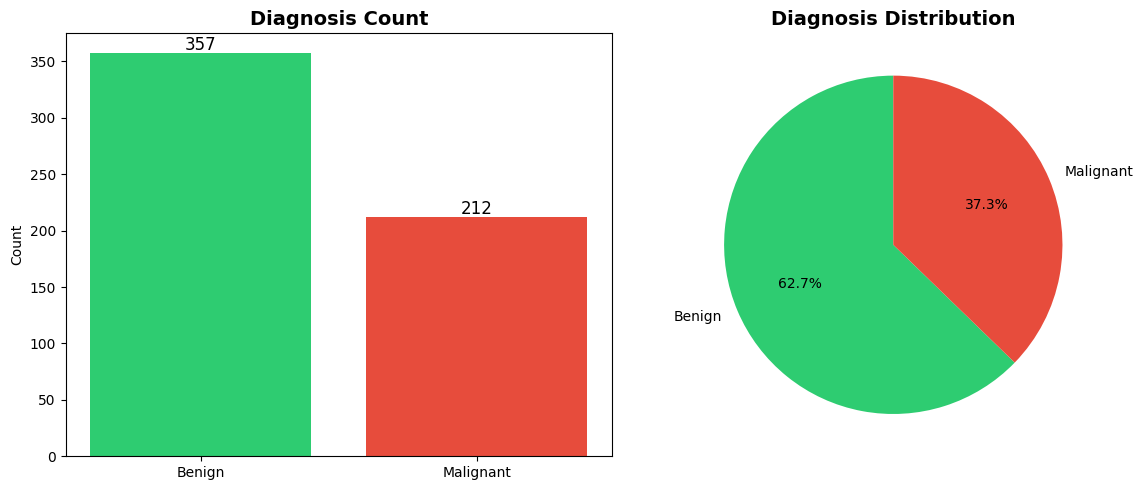

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
counts = df['diagnosis'].value_counts()
axes[0].bar(['Benign', 'Malignant'], counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Diagnosis Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 3, str(val), ha='center', fontsize=12)

# pie chart
axes[1].pie(counts.values, labels=['Benign', 'Malignant'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Diagnosis Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/diagnosis_distribution.png', dpi=150)
plt.show()

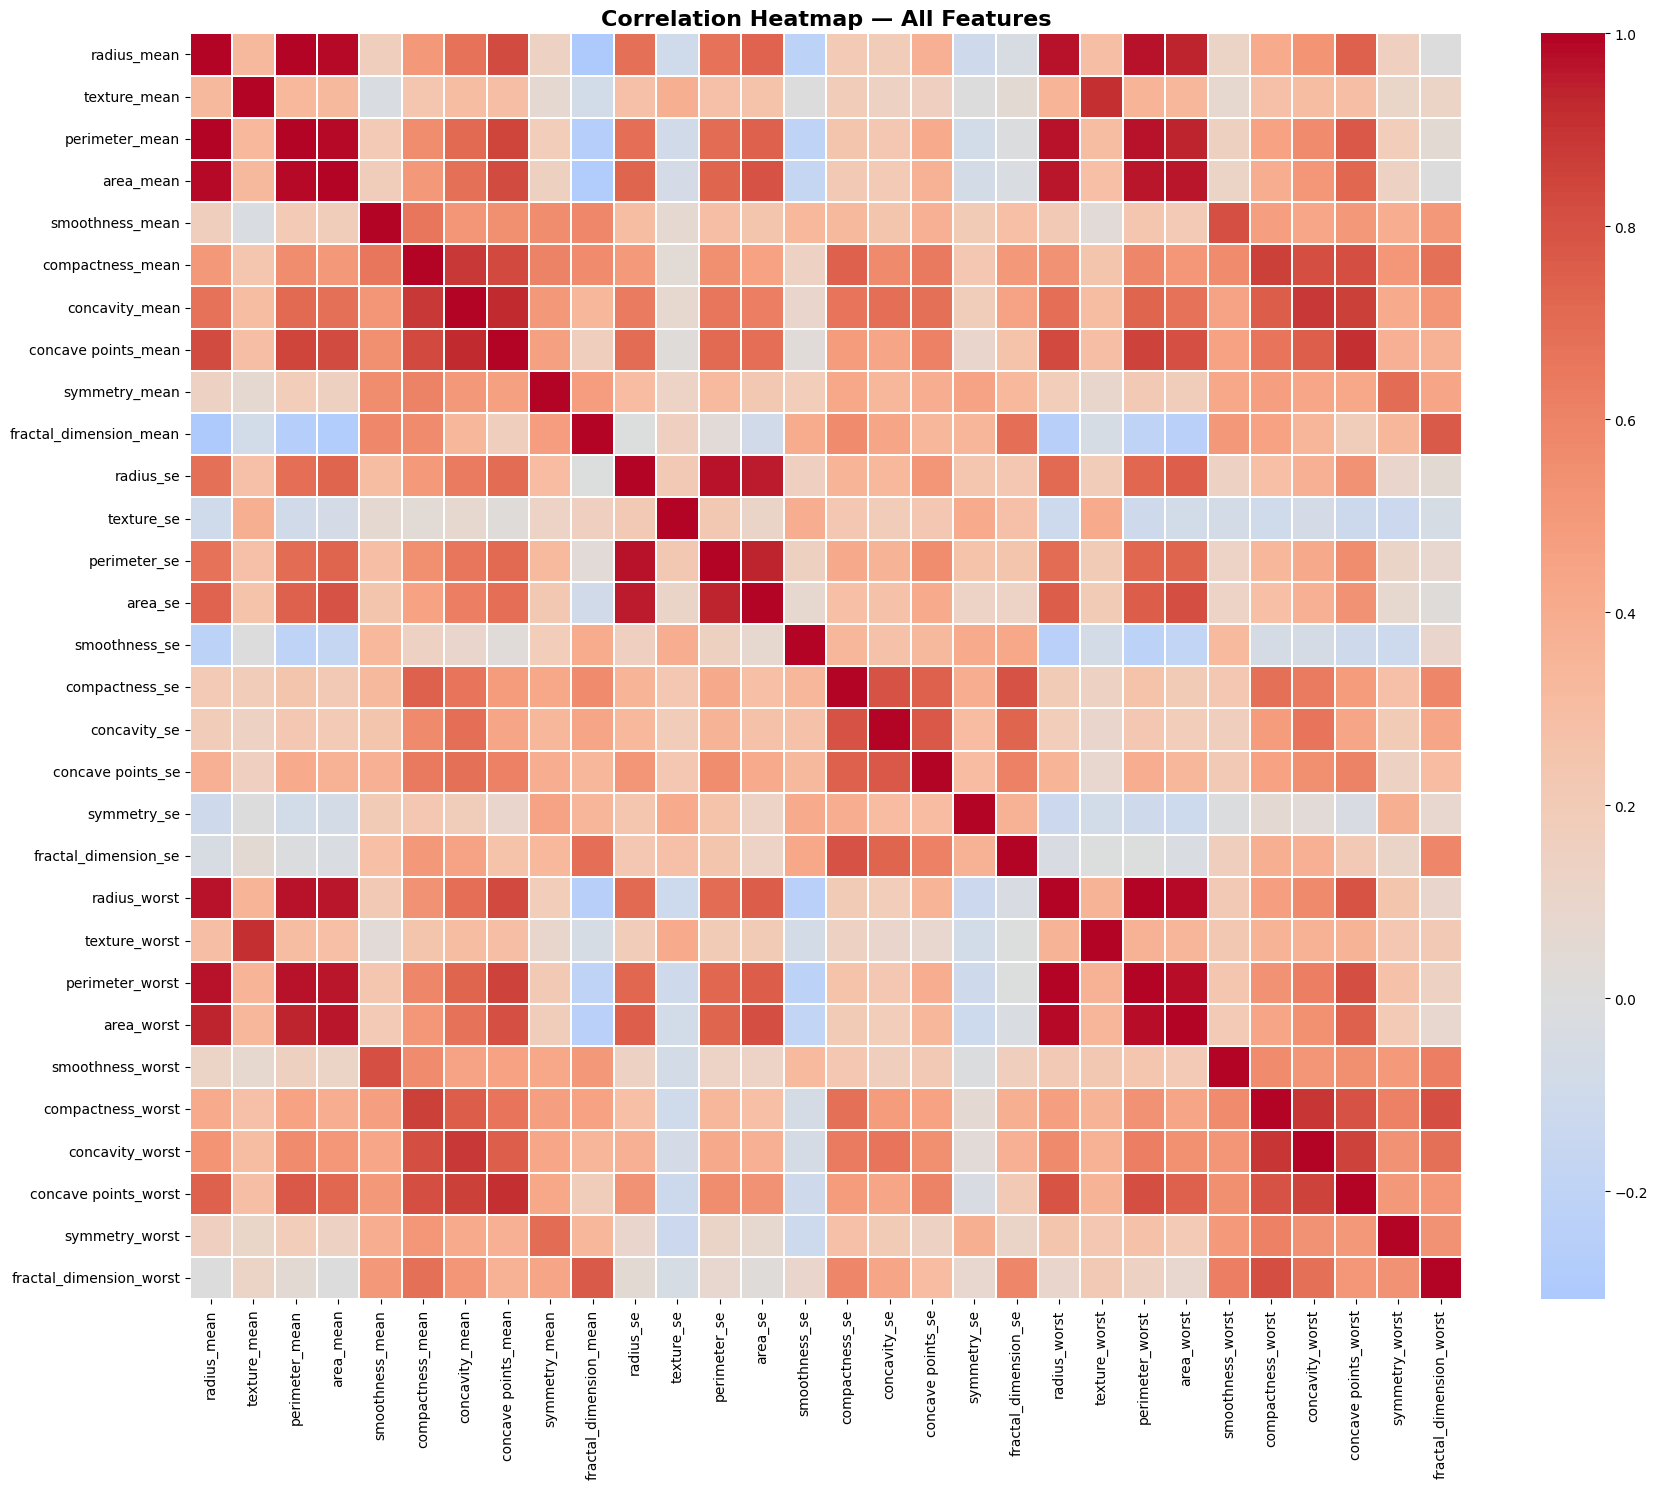

In [9]:
fig, ax = plt.subplots(figsize=(18, 15))

corr = df.drop(columns='diagnosis').corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax)

ax.set_title('Correlation Heatmap — All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap_all.png', dpi=150)
plt.show()